In [1]:
import h5py
import os 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATASET_PATH = r'../Dataset/Data/quark-gluon_data-set_n139306.hdf5'

In [9]:
def open_dataset(dataset_path):
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(f"The dataset path {dataset_path} does not exist.")
    else:
        with h5py.File(dataset_path, 'r') as f:
            for key, value in f.items():
                print(f"{key}: {value}") 
                print(f'maximum value of {key}: {np.max(value)}')

In [10]:
open_dataset(DATASET_PATH)

X_jets: <HDF5 dataset "X_jets": shape (139306, 125, 125, 3), type "<f4">
maximum value of X_jets: 756.5962524414062
m0: <HDF5 dataset "m0": shape (139306,), type "<f4">
maximum value of m0: 75.95049285888672
pt: <HDF5 dataset "pt": shape (139306,), type "<f4">
maximum value of pt: 337.0517272949219
y: <HDF5 dataset "y": shape (139306,), type "<f4">
maximum value of y: 1.0


X_jets is our image data with shape (num_samples, height, width, channels)
y_labels is our label data with shape (num_samples, 1)
m0 and pt are additional features with shape (num_samples, 1)

Some values are so large so we should normalize them.

In [ ]:
def plot_sample_images(X, y, num_samples=5):
    titles = ["ECAL", "HCAL", "Tracks"]

    for i in range(num_samples):
        jet = X[i]  
        label = int(y[i])

        plt.figure(figsize=(12, 3))
        for c in range(3):
            plt.subplot(1, 3, c+1)
            plt.imshow(jet[:, :, c], cmap="inferno")
            plt.title(f"{titles[c]} | Label: {label}")
            plt.axis("off")
        plt.show()


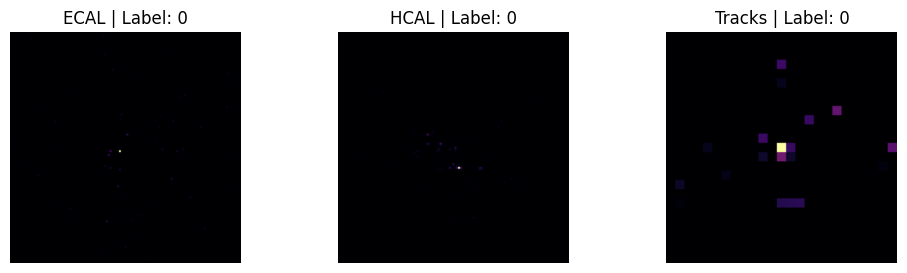

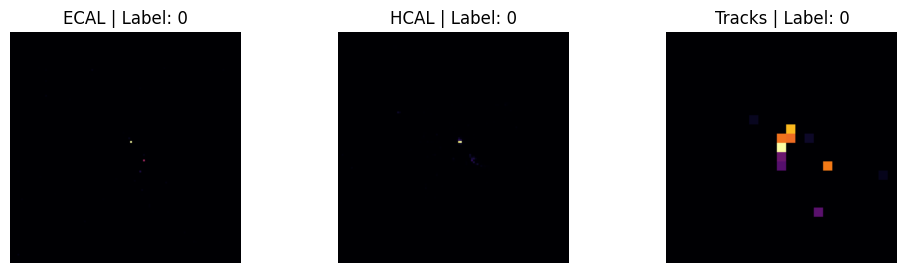

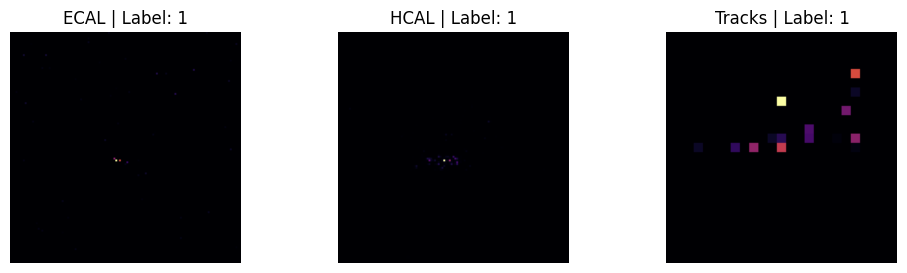

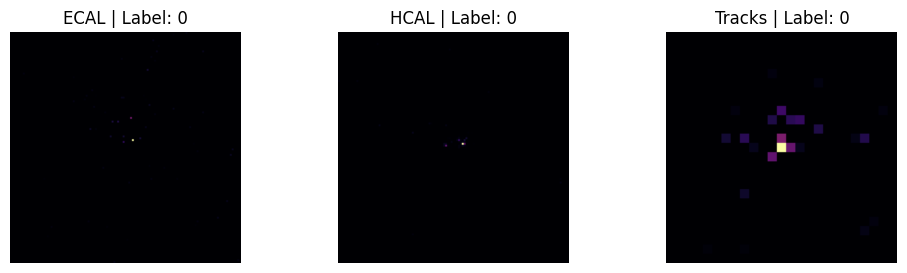

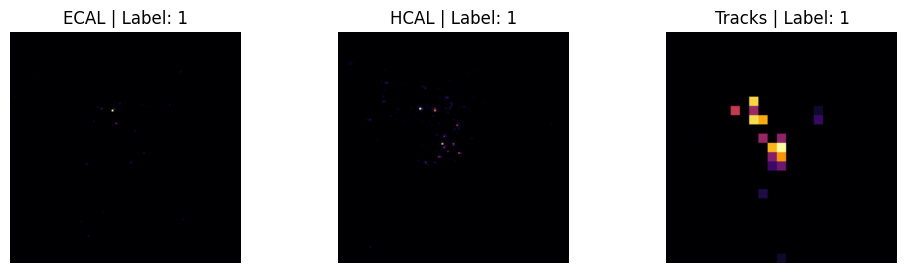

In [16]:
with h5py.File(DATASET_PATH, 'r') as f:
    X_jets = f['X_jets'][:5]
    y_labels = f['y'][:5]
    
    plot_sample_images(X_jets, y_labels)